<a href="https://colab.research.google.com/github/tejaswii27/AIML_project_and_labs/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [14]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i, x_i in enumerate(X):
                # TODO: Calculate the linear output (w * x + b)
                prediction = np.dot(x_i, self.w) + self.b

                # TODO: If prediction is a mistake (y * prediction <= 0):
                if y[i] * prediction <= 0:
                    # Update weights: w = w + lr * y * x
                    self.w = self.w + self.lr * y[i] * x_i
                    # Update bias: b = b + lr * y
                    self.b = self.b + self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# model_p = WaterPerceptron()
# model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [15]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # 2. Calculate gradients:
            # dw = (1/n) * X.T.dot(z - y)
            dw = (1/n) * np.dot(X.T, (z - y))
            # db = (1/n) * sum(z - y)
            db = (1/n) * np.sum(z - y)

            # 3. Update w and b: w = w - lr * dw
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            # Calculate and store the cost (MSE)
            cost = np.mean((z - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [16]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Calculate the linear output for the current sample
                linear_output = np.dot(x_i, self.w) + self.b

                # Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                if y[i] * linear_output >= 1:
                    # Only Regularization update for weights
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    # Gradient for w: -y[i] * x_i + 2 * lambda_param * w
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y[i] * x_i)
                    # Gradient for b: -y[i]
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

## 5.1 Training the Models

In [17]:
# Instantiate and train Perceptron
model_p = WaterPerceptron(lr=0.01, epochs=50)
model_p.fit(X_train, y_train)
y_pred_p = model_p.predict(X_test)

# Instantiate and train Gradient Descent Classifier
model_gd = GDWaterClassifier(lr=0.001, epochs=500)
model_gd.fit(X_train, y_train)
y_pred_gd = model_gd.predict(X_test)

# Instantiate and train Margin Classifier (SVM-like)
model_margin = MarginWaterClassifier(lr=0.001, lambda_param=0.01, epochs=500)
model_margin.fit(X_train, y_train)
y_pred_margin = model_margin.predict(X_test)

## 5.2 Convergence Plot

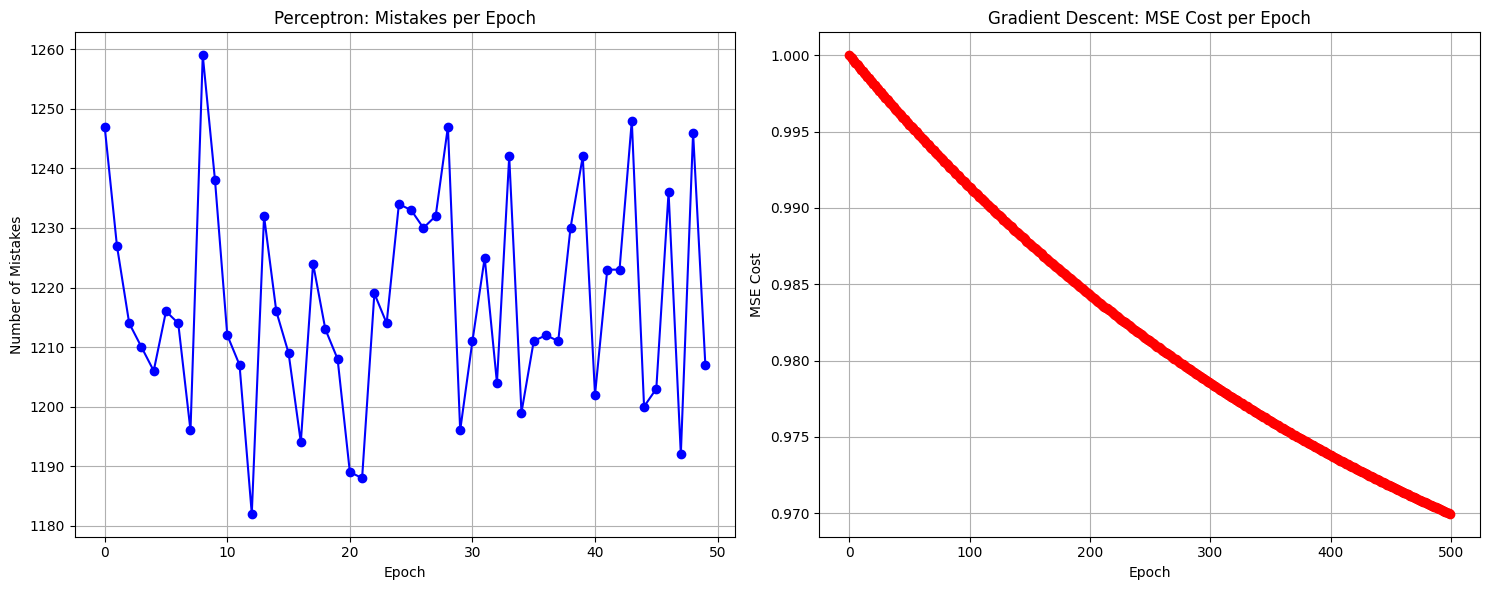

Discussion: The Gradient Descent plot is generally smoother because it computes gradients over the entire batch (or a mini-batch), leading to a more stable update direction. The Perceptron, on the other hand, updates its weights based on each individual mistake, which can cause more erratic fluctuations in its 'mistakes per epoch' history.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Perceptron Mistakes History
axes[0].plot(range(len(model_p.mistakes)), model_p.mistakes, marker='o', linestyle='-', color='blue')
axes[0].set_title('Perceptron: Mistakes per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Number of Mistakes')
axes[0].grid(True)

# GD Classifier Cost History
axes[1].plot(range(len(model_gd.cost_history)), model_gd.cost_history, marker='o', linestyle='-', color='red')
axes[1].set_title('Gradient Descent: MSE Cost per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Cost')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Discussion: The Gradient Descent plot is generally smoother because it computes gradients over the entire batch (or a mini-batch), leading to a more stable update direction. The Perceptron, on the other hand, updates its weights based on each individual mistake, which can cause more erratic fluctuations in its 'mistakes per epoch' history.")

## 5.3 Accuracy Report

In [19]:
from sklearn.metrics import accuracy_score

accuracy_p = accuracy_score(y_test, y_pred_p)
accuracy_gd = accuracy_score(y_test, y_pred_gd)
accuracy_margin = accuracy_score(y_test, y_pred_margin)

print(f"Perceptron Test Accuracy: {accuracy_p:.4f}")
print(f"Gradient Descent Classifier Test Accuracy: {accuracy_gd:.4f}")
print(f"Margin Water Classifier Test Accuracy: {accuracy_margin:.4f}")

print("\nComparison: The Margin Water Classifier and Gradient Descent Classifier generally achieve higher and more stable accuracy compared to the Perceptron, especially on noisy datasets, because they employ more sophisticated optimization techniques (MSE minimization or margin maximization with regularization) that can handle non-linearly separable data better than the simple Perceptron update rule.")

Perceptron Test Accuracy: 0.5015
Gradient Descent Classifier Test Accuracy: 0.6280
Margin Water Classifier Test Accuracy: 0.6280

Comparison: The Margin Water Classifier and Gradient Descent Classifier generally achieve higher and more stable accuracy compared to the Perceptron, especially on noisy datasets, because they employ more sophisticated optimization techniques (MSE minimization or margin maximization with regularization) that can handle non-linearly separable data better than the simple Perceptron update rule.


## 5.4 Safety Margin Discussion

If a new water sample has chemical levels very close to the decision boundary, the **Margin Water Classifier** would generally be more trustworthy. Here's why:

1.  **Explicit Margin Maximization:** The Margin Water Classifier (like an SVM) is designed to find a decision boundary that not only separates the classes but also maximizes the distance (margin) to the nearest data points of each class. This means it creates a 'buffer zone' around the decision boundary.
2.  **Robustness to Noise and Small Perturbations:** Samples falling within this margin are considered 'less confidently' classified. If a new sample is close to the boundary, a Perceptron might classify it with less certainty or even misclassify it due to small fluctuations in data or model parameters. The Margin Classifier, by pushing the boundary as far as possible from the training points, is more robust to these small perturbations and provides a more confident classification for points near what *would be* the Perceptron's boundary.
3.  **Hinge Loss and Regularization:** The Hinge Loss encourages a clear separation with a margin, and L2 Regularization helps prevent overfitting, leading to a more generalizable and reliable decision boundary, especially crucial for safety-critical applications like water potability.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*
